In [12]:
import sys 
from pathlib import Path
sys.path.append(str(Path(__name__).resolve().parents[2]))
import importlib
import utils 
importlib.reload(utils)
from utils.dataset import ProcessedDataset, load_geneset_dataset, split_by_indices, save_predicitons
from utils.dna import Genes, create_template_from_genes
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt

In [9]:
GENESET = "test"
X_train_sc, X_val_sc, X_test_sc, Y_train, Y_val, Y_test, train_images, val_images, test_images, scaler_x = load_geneset_dataset(GENESET)
X_train = np.concatenate([X_train_sc, X_val_sc])
Y_train = np.concatenate([Y_train, Y_val])
train_images = np.concatenate([train_images, val_images])

100%|██████████| 1/1 [00:00<00:00, 127.70it/s]


## Display genes on plane

In [6]:
# run umap on X 
from umap import UMAP
u = UMAP(n_components=2)
X_train_umap = u.fit_transform(X_train)

plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1])
plt.show()

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'X_train' is not defined

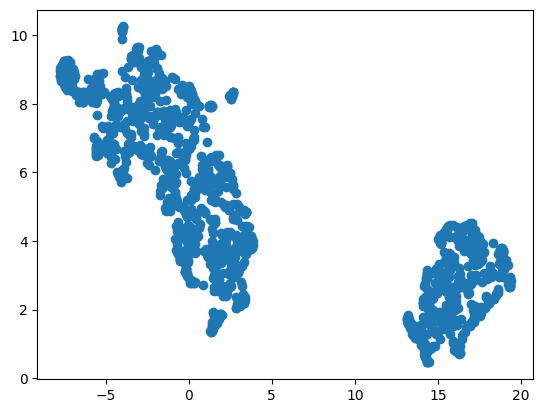

In [ ]:
u = UMAP(n_components=2)
X_test_umap = u.fit_transform(X_test)

plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1])
plt.show()

# Model

In [11]:
import importlib
import models.diffusion.ddpm as ddpm
import models.callbacks as callbacks
importlib.reload(ddpm)
importlib.reload(callbacks)
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger
import torch 
from models.callbacks import MetricsCallback
from models.diffusion.ddpm import ConditionalDDPM, SimpleCondNet, ConditionalNetworkConfig
import torch.utils.data 
import wandb 

TRAIN = True
MODEL_CHECKPOINT = "/Users/czyjtu/dev/prompt2avatar/notebooks/training/lightning_logs/version_74/checkpoints/epoch=999-step=106000.ckpt"
WANDB_DIR = Path("/Users/maciej.czyjt/private/prompt2avatar/checkpoints/diffusion") / GENESET
WANDB_DIR.mkdir(exist_ok=True, parents=True)


X_th = torch.tensor(X_train).float()
Y_th = torch.tensor(Y_train).float()

train_dataset = torch.utils.data.TensorDataset(X_th, Y_th)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test_sc).float(), torch.tensor(Y_test).float())
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

if TRAIN:
    with wandb.init(
        project="prompt2avatar", entity="czyjtu",
        tags=["diffusion", GENESET], group="diffusion" + GENESET, dir=WANDB_DIR
        ) as wandb_run:
        checkpoint_callback = ModelCheckpoint(
            monitor='val_loss',
            dirpath=WANDB_DIR / 'model_checkpoints',
            filename='best_model',
            save_top_k=1,
            mode='min'
        )
        wandb_logger = WandbLogger(project='prompt2avatar', entity="czyjtu", log_model="all", experiment=wandb_run)
        net_config = ConditionalNetworkConfig(
            input_dim=X_th.shape[1], 
            condition_dim=Y_th.shape[1], 
            condition_emb_dim=128, 
            inner_dim=[256, 256, 256, 256, 256], 
            condition_encoder_dim=[128, 128, 128, 128]
        )
        ddpm_len = ConditionalDDPM(net_config)
        # print(Y_ltr.shape())
        callback = MetricsCallback(
            torch.tensor(val_images).float(),
            torch.tensor(X_test_sc).float(), 
            torch.tensor(Y_test).float(), 
            scaler_x
        )

        trainer = pl.Trainer(
            max_epochs=1000, 
            callbacks=[callback, checkpoint_callback], 
            logger=wandb_logger, 
            accelerator="mps"
            )
        trainer.fit(ddpm_len, train_dataloaders=train_loader, val_dataloaders=test_loader)
else:
    cond_ddpm = ConditionalDDPM.load_from_checkpoint(MODEL_CHECKPOINT)
    cond_ddpm = cond_ddpm.to("cpu")
    cond_ddpm.eval()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: czyjtu. Use `wandb login --relogin` to force relogin


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type          | Params | Mode 
-----------------------------------------------
0 | net  | SimpleCondNet | 891 K  | train
-----------------------------------------------
891 K     Trainable params
0         Non-trainable params
891 K     Total params
3.565     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 999: 100%|██████████| 106/106 [00:03<00:00, 27.20it/s, v_num=oaim, training_loss=0.00634, val_loss=0.014, RMSE=0.0194, Scaled RMSE=2.820, MAE=0.0147, R2=0.984]  

`Trainer.fit` stopped: `max_epochs=1000` reached.


Epoch 999: 100%|██████████| 106/106 [00:03<00:00, 27.19it/s, v_num=oaim, training_loss=0.00634, val_loss=0.014, RMSE=0.0194, Scaled RMSE=2.820, MAE=0.0147, R2=0.984]


MAE,█▄▄▄▄▃▄▄▄▄▄▃▃▄▄▄▃▄▄▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
R2,▁▄▃▃▃▄▃▃▃▃▃▃▄▃▄▃▄▄▄▄▇███████████████████
RMSE,█▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▄▄▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Scaled RMSE,█▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
trainer/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
training_loss,▇▆▄▅▆▇▄▅▅▄▃▄█▄▄▄▅▇▄▆▃▂▂▃▃▃▂▃▂▂▂▂▃▂▁▂▁▁▂▂
val_loss,█▆▅▅▅▅▅▆▄▅▄▄▅▄▅▄▄▄▃▄▃▂▁▂▂▂▂▂▁▃▁▁▂▁▂▂▁▁▁▂
MAE,0.0147
R2,0.98411
RMSE,0.01944


In [15]:
ddpm_len.to("mps")
X_pred = callback.sample_model(ddpm_len).cpu().numpy()
pred_path = Path("/Users/maciej.czyjt/private/prompt2avatar/experiments/test_geneset_embeddings/predicted_dnas_diffusion")
save_predicitons(X_pred, scaler_x, pred_path, GENESET)

100%|██████████| 1/1 [00:00<00:00, 89.57it/s]


In [17]:
1500 * 4 / 60 / 60


1.6666666666666667

In [18]:
len(X_test_sc)

1499

In [20]:
len(X_train)

13491